In [1]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns 
from scipy import stats        

In [2]:
df = pd.read_csv(r"C:\Users\Dell\Downloads\retail_large_dataset.csv")

In [3]:
df.head()

,customer_id,age,gender,city,state,customer_segment,order_id,order_date,product_category,product_subcategory,product_price,quantity,discount_percentage,final_price,payment_method,shipping_type,delivery_days,return_status
0,C10000,56,Male,Hyderabad,Telangana,New,O50000,10/05/2025,Health,Protein Powder,38658,3,7,107855.82,Debit Card,Standard,5,No
1,C10001,36,Male,Pune,Maharashtra,Premium,O50001,27/11/2023,Electronics,Smartphone,22462,4,20,71878.40,Cash on Delivery,Standard,4,Yes
2,C10002,20,Male,Kolkata,West Bengal,New,O50002,08/02/2025,Fashion,Women Dress,56601,2,27,82637.46,Credit Card,Standard,5,No
3,C10003,39,Female,Jaipur,Rajasthan,New,O50003,19/04/2024,Beauty,Perfume,26158,3,9,71411.34,UPI,Standard,3,No
4,C10004,20,Male,Chennai,Tamil Nadu,Premium,O50004,08/10/2024,Beauty,Shampoo,31240,1,6,29365.60,UPI,Standard,2,No


In [4]:
df.tail()

,customer_id,age,gender,city,state,customer_segment,order_id,order_date,product_category,product_subcategory,product_price,quantity,discount_percentage,final_price,payment_method,shipping_type,delivery_days,return_status
99995,C109995,29,Female,Pune,Maharashtra,Regular,O149995,11/06/2024,Health,Supplements,49293,1,11,43870.77,Debit Card,Standard,9,No
99996,C109996,28,Male,Mumbai,Maharashtra,Premium,O149996,27/04/2024,Fashion,Men T-Shirt,5722,2,22,8926.32,Cash on Delivery,Express,1,No
99997,C109997,44,Female,Jaipur,Rajasthan,Premium,O149997,14/04/2024,Grocery,Snacks,6311,4,11,22467.16,Cash on Delivery,Express,9,No
99998,C109998,45,Male,Jaipur,Rajasthan,Premium,O149998,08/09/2024,Beauty,Shampoo,46888,1,28,33759.36,Debit Card,Standard,1,No
99999,C109999,19,Male,Kolkata,West Bengal,New,O149999,15/11/2025,Health,Supplements,37361,3,3,108720.51,Credit Card,Standard,2,No


In [5]:
df.shape

(100000, 18)

In [6]:
df.columns

Index(['customer_id', 'age', 'gender', 'city', 'state', 'customer_segment',
       'order_id', 'order_date', 'product_category', 'product_subcategory',
       'product_price', 'quantity', 'discount_percentage', 'final_price',
       'payment_method', 'shipping_type', 'delivery_days', 'return_status'],
      dtype='object')

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 18 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   customer_id          100000 non-null  object 
 1   age                  100000 non-null  int64  
 2   gender               100000 non-null  object 
 3   city                 100000 non-null  object 
 4   state                100000 non-null  object 
 5   customer_segment     100000 non-null  object 
 6   order_id             100000 non-null  object 
 7   order_date           100000 non-null  object 
 8   product_category     100000 non-null  object 
 9   product_subcategory  100000 non-null  object 
 10  product_price        100000 non-null  int64  
 11  quantity             100000 non-null  int64  
 12  discount_percentage  100000 non-null  int64  
 13  final_price          100000 non-null  float64
 14  payment_method       100000 non-null  object 
 15  shipping_type     

In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df.describe()

,age,product_price,quantity,discount_percentage,final_price,delivery_days
count,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,41.561830,30164.526720,2.501790,15.009890,64165.723382,5.505540
std,13.852439,17139.679807,1.120058,8.953296,49969.280150,2.872868
min,18.000000,500.000000,1.000000,0.000000,357.000000,1.000000
25%,30.000000,15375.000000,1.000000,7.000000,24705.000000,3.000000
50%,42.000000,30148.000000,3.000000,15.000000,49752.390000,5.000000
75%,54.000000,44957.000000,4.000000,23.000000,94046.070000,8.000000
max,65.000000,59998.000000,4.000000,30.000000,239980.000000,10.000000


In [10]:
df["order_date"] = pd.to_datetime(df["order_date"], format="%d/%m/%Y")

In [11]:
df["return_flag"] = df["return_status"].map({"Yes": 1, "No": 0})

In [12]:
df["age_group"] = pd.cut(df["age"], bins=[17, 29, 45, 65], labels=["18-29", "30-45", "46-65"])

In [13]:
df.info()
df[["order_date","return_status","return_flag","age","age_group"]].head(10)


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 20 columns):
 #   Column               Non-Null Count   Dtype         
---  ------               --------------   -----         
 0   customer_id          100000 non-null  object        
 1   age                  100000 non-null  int64         
 2   gender               100000 non-null  object        
 3   city                 100000 non-null  object        
 4   state                100000 non-null  object        
 5   customer_segment     100000 non-null  object        
 6   order_id             100000 non-null  object        
 7   order_date           100000 non-null  datetime64[ns]
 8   product_category     100000 non-null  object        
 9   product_subcategory  100000 non-null  object        
 10  product_price        100000 non-null  int64         
 11  quantity             100000 non-null  int64         
 12  discount_percentage  100000 non-null  int64         
 13  final_price    

,order_date,return_status,return_flag,age,age_group
0,2025-05-10,No,0,56,46-65
1,2023-11-27,Yes,1,36,30-45
2,2025-02-08,No,0,20,18-29
3,2024-04-19,No,0,39,30-45
4,2024-10-08,No,0,20,18-29
5,2025-02-15,No,0,31,30-45
6,2023-02-04,No,0,24,18-29
7,2024-07-19,No,0,19,18-29
8,2025-09-22,No,0,51,46-65
9,2024-12-20,No,0,57,46-65


In [14]:
df["discount_band"] = pd.cut(df["discount_percentage"], bins=[-1, 10, 20, 30],
                             labels=["Low (0-10%)", "Moderate (11-20%)", "High (21-30%)"])

In [15]:
num_cols = ["age", "product_price", "quantity", "discount_percentage", "final_price", "delivery_days"]

In [16]:
df[["order_date", "return_flag", "age_group", "discount_band"]].head()

,order_date,return_flag,age_group,discount_band
0,2025-05-10,0,46-65,Low (0-10%)
1,2023-11-27,1,30-45,Moderate (11-20%)
2,2025-02-08,0,18-29,High (21-30%)
3,2024-04-19,0,30-45,Low (0-10%)
4,2024-10-08,0,18-29,Low (0-10%)


**UNIVARIATE ANALYSIS**

**Numerical Variable**

In [17]:
df[num_cols].mean()

age                       41.561830
product_price          30164.526720
quantity                   2.501790
discount_percentage       15.009890
final_price            64165.723382
delivery_days              5.505540
dtype: float64

In [18]:
df[num_cols].median()

age                       42.00
product_price          30148.00
quantity                   3.00
discount_percentage       15.00
final_price            49752.39
delivery_days              5.00
dtype: float64

In [19]:
df[num_cols].std()

age                       13.852439
product_price          17139.679807
quantity                   1.120058
discount_percentage        8.953296
final_price            49969.280150
delivery_days              2.872868
dtype: float64

In [20]:
df[num_cols].min()

age                     18.0
product_price          500.0
quantity                 1.0
discount_percentage      0.0
final_price            357.0
delivery_days            1.0
dtype: float64

In [21]:
df[num_cols].max()

age                        65.0
product_price           59998.0
quantity                    4.0
discount_percentage        30.0
final_price            239980.0
delivery_days              10.0
dtype: float64

In [22]:
df[num_cols].skew()

age                   -0.004988
product_price          0.003249
quantity              -0.003067
discount_percentage   -0.003597
final_price            0.934747
delivery_days          0.002270
dtype: float64

In [23]:
df[num_cols].kurt()

age                   -1.201172
product_price         -1.195106
quantity              -1.364612
discount_percentage   -1.201628
final_price            0.169047
delivery_days         -1.221514
dtype: float64

In [24]:
summary = df[num_cols].agg(["mean", "median", "std", "min", "max"]).T
summary["skewness"] = df[num_cols].skew()
summary["kurtosis"] = df[num_cols].kurt()
summary

,mean,median,std,min,max,skewness,kurtosis
age,41.561830,42.00,13.852439,18.0,65.0,-0.004988,-1.201172
product_price,30164.526720,30148.00,17139.679807,500.0,59998.0,0.003249,-1.195106
quantity,2.501790,3.00,1.120058,1.0,4.0,-0.003067,-1.364612
discount_percentage,15.009890,15.00,8.953296,0.0,30.0,-0.003597,-1.201628
final_price,64165.723382,49752.39,49969.280150,357.0,239980.0,0.934747,0.169047
delivery_days,5.505540,5.00,2.872868,1.0,10.0,0.002270,-1.221514


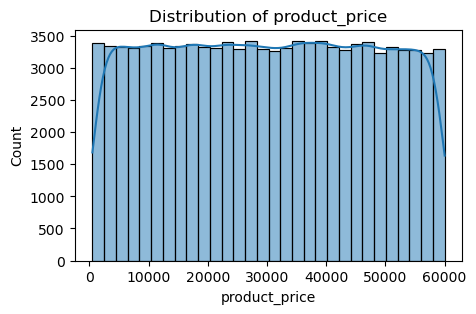

In [25]:
plt.figure(figsize=(5,3))
sns.histplot(df["product_price"], bins=30, kde=True)
plt.title("Distribution of product_price")
plt.show()

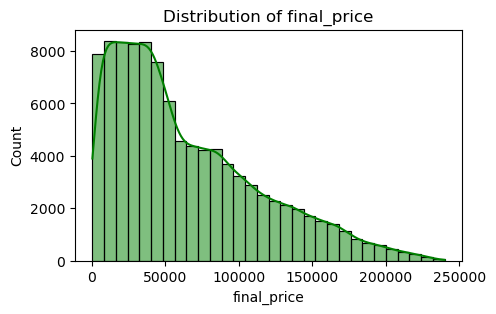

In [26]:
plt.figure(figsize=(5,3))
sns.histplot(df["final_price"], bins=30, kde=True, color="green")
plt.title("Distribution of final_price")
plt.show()

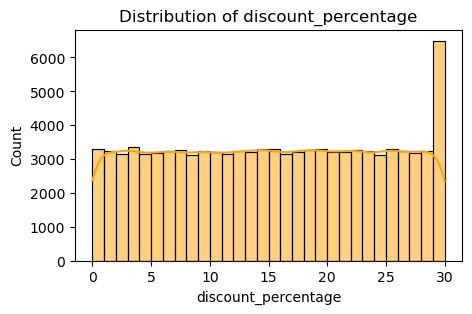

In [27]:
plt.figure(figsize=(5,3))
sns.histplot(df["discount_percentage"], bins=30, kde=True, color="orange")
plt.title("Distribution of discount_percentage")
plt.show()

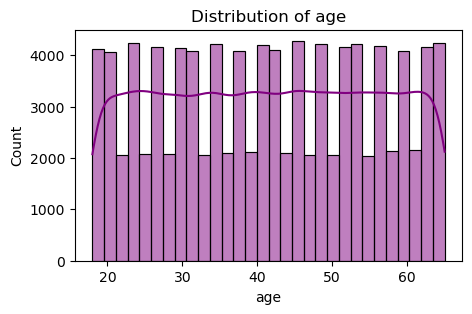

In [28]:
plt.figure(figsize=(5,3))
sns.histplot(df["age"], bins=30, kde=True, color="purple")
plt.title("Distribution of age")
plt.show()

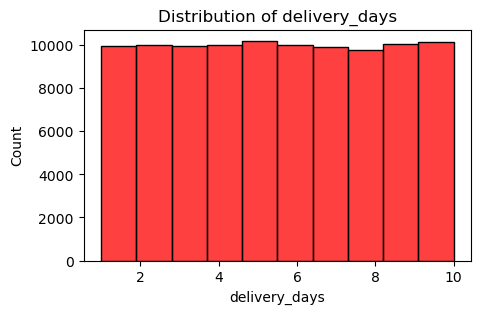

In [29]:
plt.figure(figsize=(5,3))
sns.histplot(df["delivery_days"], bins=10, kde=False, color="red")
plt.title("Distribution of delivery_days")
plt.show()

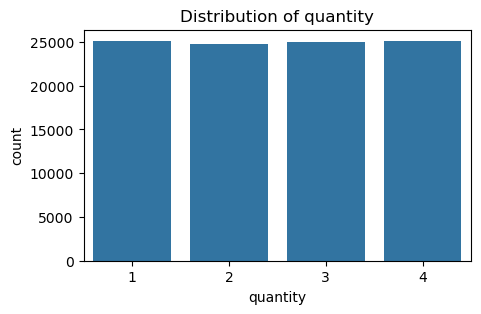

In [30]:
plt.figure(figsize=(5,3))
sns.countplot(x="quantity", data=df)
plt.title("Distribution of quantity")
plt.show()

**Catagorical Variable**

In [31]:
df["product_category"].value_counts()

product_category
Health            16858
Home & Kitchen    16848
Fashion           16613
Grocery           16592
Electronics       16576
Beauty            16513
Name: count, dtype: int64

In [32]:
df["product_category"].value_counts(normalize=True) * 100

product_category
Health            16.858
Home & Kitchen    16.848
Fashion           16.613
Grocery           16.592
Electronics       16.576
Beauty            16.513
Name: proportion, dtype: float64

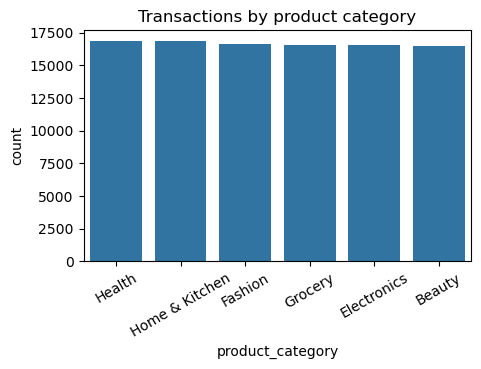

In [33]:
plt.figure(figsize=(5,3))
sns.countplot(x="product_category", data=df, order=df["product_category"].value_counts().index)
plt.title("Transactions by product category")
plt.xticks(rotation=30)
plt.show()

In [34]:
df["customer_segment"].value_counts()

customer_segment
New        33488
Regular    33361
Premium    33151
Name: count, dtype: int64

In [35]:
df["customer_segment"].value_counts(normalize=True) * 100

customer_segment
New        33.488
Regular    33.361
Premium    33.151
Name: proportion, dtype: float64

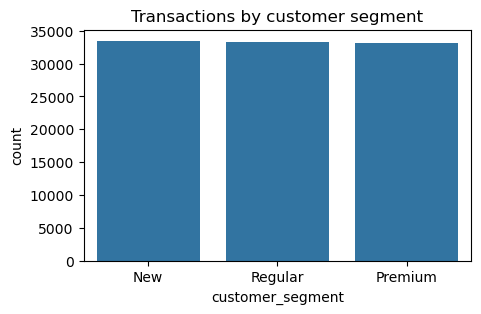

In [36]:
plt.figure(figsize=(5,3))
sns.countplot(x="customer_segment", data=df, order=df["customer_segment"].value_counts().index)
plt.title("Transactions by customer segment")
plt.show()

In [37]:
df["payment_method"].value_counts()

payment_method
Credit Card         25307
UPI                 25139
Cash on Delivery    24994
Debit Card          24560
Name: count, dtype: int64

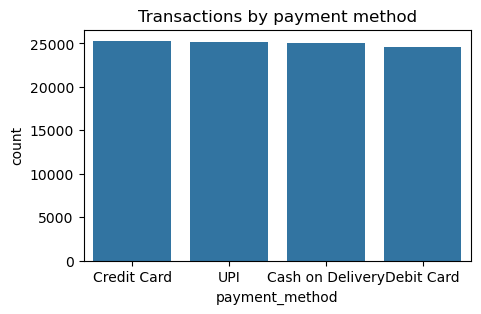

In [38]:
plt.figure(figsize=(5,3))
sns.countplot(x="payment_method", data=df, order=df["payment_method"].value_counts().index)
plt.title("Transactions by payment method")
plt.show()

In [39]:
df["return_status"].value_counts()

return_status
No     85189
Yes    14811
Name: count, dtype: int64

In [40]:
return_rate = df["return_flag"].mean() * 100
print("Return rate:", round(return_rate, 2), "%")

Return rate: 14.81 %


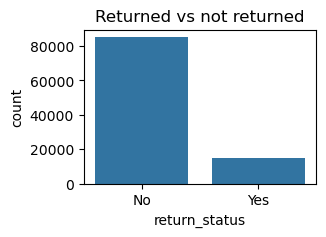

In [41]:
plt.figure(figsize=(3,2))
sns.countplot(x="return_status", data=df)
plt.title("Returned vs not returned")
plt.show()

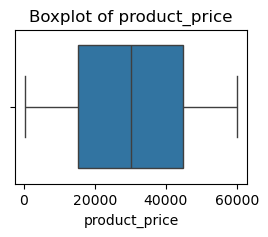

In [42]:
plt.figure(figsize=(3,2))
sns.boxplot(x=df["product_price"])
plt.title("Boxplot of product_price")
plt.show()

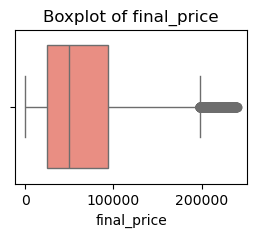

In [43]:
plt.figure(figsize=(3,2))
sns.boxplot(x=df["final_price"], color="salmon")
plt.title("Boxplot of final_price")
plt.show()

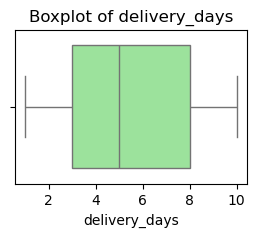

In [44]:
plt.figure(figsize=(3,2))
sns.boxplot(x=df["delivery_days"], color="lightgreen")
plt.title("Boxplot of delivery_days")
plt.show()

In [45]:
Q1 = df["final_price"].quantile(0.25)
Q3 = df["final_price"].quantile(0.75)

In [46]:
IQR = Q3 - Q1

In [47]:
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR
print("Lower limit:", round(lower, 2))
print("Upper limit:", round(upper, 2))

Lower limit: -79306.6
Upper limit: 198057.68


In [48]:
final_outliers = df[(df["final_price"] < lower) | (df["final_price"] > upper)]
print("Number of outliers in final_price:", len(final_outliers))
print("Percentage:", round(len(final_outliers) / len(df) * 100, 2), "%")

Number of outliers in final_price: 1335
Percentage: 1.33 %


In [49]:
for col in ["product_price", "delivery_days"]:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    outliers = df[(df[col] < q1 - 1.5 * iqr) | (df[col] > q3 + 1.5 * iqr)]
    print(col, "-> outliers:", len(outliers))

product_price -> outliers: 0
delivery_days -> outliers: 0


In [50]:
df["z_final_price"] = stats.zscore(df["final_price"])

In [51]:
z_outliers = df[df["z_final_price"].abs() > 3]
print("Z-score outliers in final_price:", len(z_outliers))

Z-score outliers in final_price: 503


In [52]:
final_outliers["quantity"].value_counts()

quantity
4    1335
Name: count, dtype: int64

In [53]:
final_outliers["product_category"].value_counts()

product_category
Grocery           247
Beauty            235
Home & Kitchen    235
Electronics       211
Fashion           204
Health            203
Name: count, dtype: int64

In [54]:
print("Average product_price (outliers):", round(final_outliers["product_price"].mean()))
print("Average product_price (all rows) :", round(df["product_price"].mean()))

Average product_price (outliers): 56249
Average product_price (all rows) : 30165


**BIVARIATE ANALYSIS**

In [55]:
df["product_price"].corr(df["final_price"])

np.float64(0.7307565728278345)

In [56]:
df["quantity"].corr(df["final_price"])

np.float64(0.5753033421480558)

In [57]:
df["discount_percentage"].corr(df["final_price"])

np.float64(-0.13733167131008542)

In [58]:
df["age"].corr(df["final_price"])

np.float64(-0.0008232425708035182)

In [59]:
df["delivery_days"].corr(df["return_flag"])

np.float64(0.0005237527726498173)

In [60]:
sample = df.sample(5000, random_state=42)

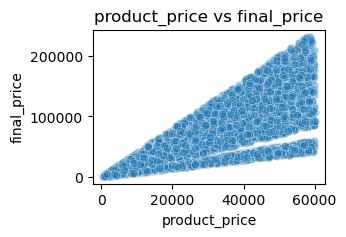

In [61]:
plt.figure(figsize=(3,2))
sns.scatterplot(x="product_price", y="final_price", data=sample, alpha=0.4)
plt.title("product_price vs final_price")
plt.show()

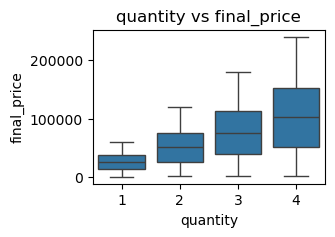

In [62]:
plt.figure(figsize=(3,2))
sns.boxplot(x="quantity", y="final_price", data=df)
plt.title("quantity vs final_price")
plt.show()

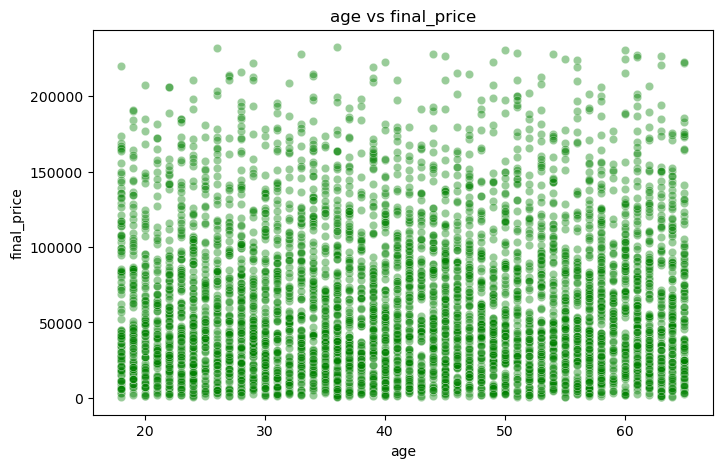

In [63]:
plt.figure(figsize=(8,5))
sns.scatterplot(x="age", y="final_price", data=sample, alpha=0.4, color="green")
plt.title("age vs final_price")
plt.show()

**Numerical VS Categorical Variable**

In [64]:
df.groupby("customer_segment")["final_price"].mean()

customer_segment
New        63766.749294
Premium    64430.451339
Regular    64303.154748
Name: final_price, dtype: float64

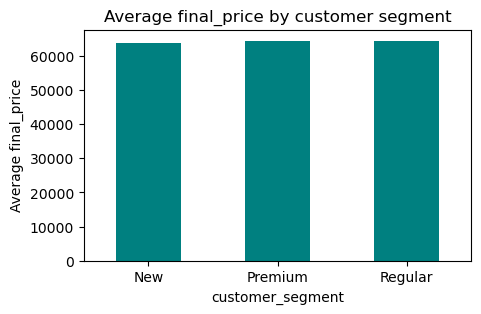

In [65]:
df.groupby("customer_segment")["final_price"].mean().plot(kind="bar", color="teal", figsize=(5,3))
plt.title("Average final_price by customer segment")
plt.ylabel("Average final_price")
plt.xticks(rotation=0)
plt.show()

In [66]:
df.groupby("product_category")["return_flag"].mean() * 100

product_category
Beauty            14.758069
Electronics       14.472732
Fashion           15.048456
Grocery           14.868611
Health            14.829754
Home & Kitchen    14.886040
Name: return_flag, dtype: float64

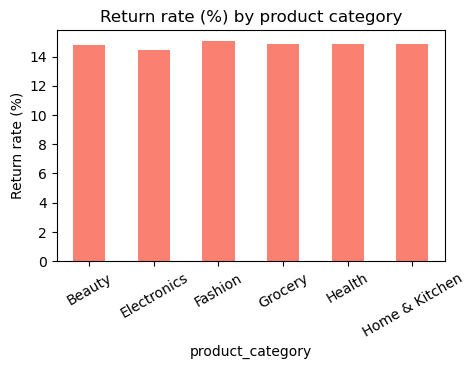

In [67]:
(df.groupby("product_category")["return_flag"].mean() * 100).plot(kind="bar", color="salmon", figsize=(5,3))
plt.title("Return rate (%) by product category")
plt.ylabel("Return rate (%)")
plt.xticks(rotation=30)
plt.show()

In [68]:
df.groupby("shipping_type")["delivery_days"].mean()

shipping_type
Express     5.497400
Standard    5.513682
Name: delivery_days, dtype: float64

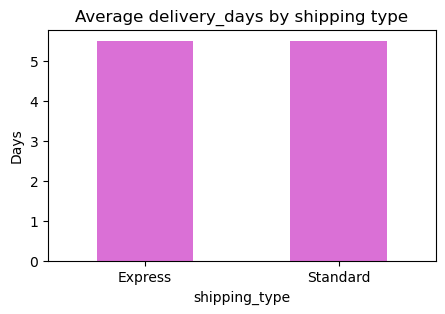

In [69]:
df.groupby("shipping_type")["delivery_days"].mean().plot(kind="bar", color="orchid", figsize=(5,3))
plt.title("Average delivery_days by shipping type")
plt.ylabel("Days")
plt.xticks(rotation=0)
plt.show()

In [70]:
seg_groups = [g["final_price"] for _, g in df.groupby("customer_segment")]
print("ANOVA p-value (segment vs final_price):", round(stats.f_oneway(*seg_groups).pvalue, 4))

ANOVA p-value (segment vs final_price): 0.1904


In [71]:
express = df[df["shipping_type"] == "Express"]["delivery_days"]
standard = df[df["shipping_type"] == "Standard"]["delivery_days"]
print("t-test p-value (Express vs Standard days):", round(stats.ttest_ind(express, standard).pvalue, 4))

t-test p-value (Express vs Standard days): 0.3702


In [72]:
table = pd.crosstab(df["product_category"], df["return_status"])
print("Chi-square p-value (category vs return):", round(stats.chi2_contingency(table)[1], 4))

Chi-square p-value (category vs return): 0.7906


In [73]:
corr = df[num_cols + ["return_flag"]].corr()

In [74]:
corr

,age,product_price,quantity,discount_percentage,final_price,delivery_days,return_flag
age,1.000000,-0.000814,-0.000129,-0.004035,-0.000823,-0.003954,0.000426
product_price,-0.000814,1.000000,0.000950,-0.002886,0.730757,0.001554,0.001125
quantity,-0.000129,0.000950,1.000000,-0.003579,0.575303,0.004017,0.002840
discount_percentage,-0.004035,-0.002886,-0.003579,1.000000,-0.137332,-0.000453,0.000678
final_price,-0.000823,0.730757,0.575303,-0.137332,1.000000,0.003789,0.002037
delivery_days,-0.003954,0.001554,0.004017,-0.000453,0.003789,1.000000,0.000524
return_flag,0.000426,0.001125,0.002840,0.000678,0.002037,0.000524,1.000000


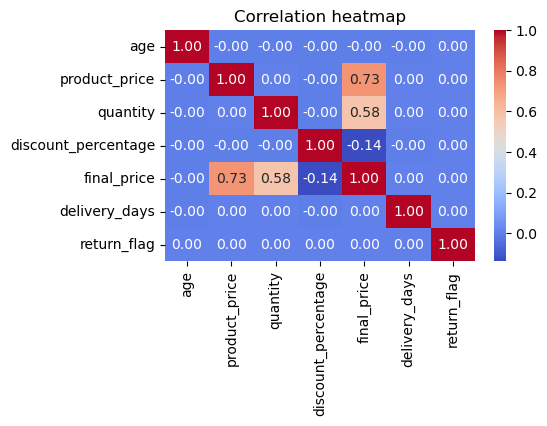

In [75]:
plt.figure(figsize=(5,3))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation heatmap")
plt.show()

In [76]:
features = ["age", "product_price", "quantity", "discount_percentage", "delivery_days"]
vif = np.diag(np.linalg.inv(df[features].corr().values))
pd.Series(vif, index=features)

age                    1.000033
product_price          1.000012
quantity               1.000030
discount_percentage    1.000038
delivery_days          1.000034
dtype: float64

**MULTIVARIATE ANALYSIS**

In [77]:
pivot1 = df.pivot_table(index="product_category", columns="discount_band",
                        values="final_price", aggfunc="sum") / 1000000
pivot1

C:\Users\Dell\AppData\Local\Temp\ipykernel_17844\526249178.py:1: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot1 = df.pivot_table(index="product_category", columns="discount_band",


discount_band,Low (0-10%),Moderate (11-20%),High (21-30%)
product_category,,,
Beauty,415.681061,340.821766,300.833668
Electronics,430.279121,338.632652,297.416850
Fashion,419.958342,342.903029,300.406982
Grocery,422.520954,343.409482,297.646771
Health,424.338100,346.039974,303.252179
Home & Kitchen,434.790585,349.634696,308.006127


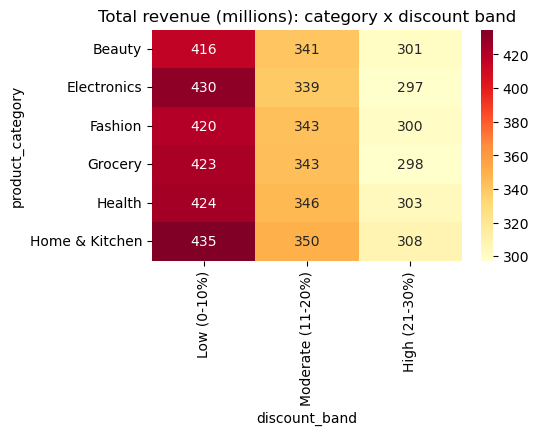

In [78]:
plt.figure(figsize=(5,3))
sns.heatmap(pivot1, annot=True, fmt=".0f", cmap="YlOrRd")
plt.title("Total revenue (millions): category x discount band")
plt.show()

In [79]:
print("Highest revenue combination:", pivot1.stack().idxmax())

Highest revenue combination: ('Home & Kitchen', 'Low (0-10%)')


In [80]:
pivot2 = df.pivot_table(index="customer_segment", columns="age_group",
                        values="final_price", aggfunc="mean", observed=True)
pivot2

age_group,18-29,30-45,46-65
customer_segment,,,
New,63715.337696,64033.116897,63586.040738
Premium,64012.797617,64827.724200,64366.406607
Regular,64252.133446,64148.958249,64456.244284


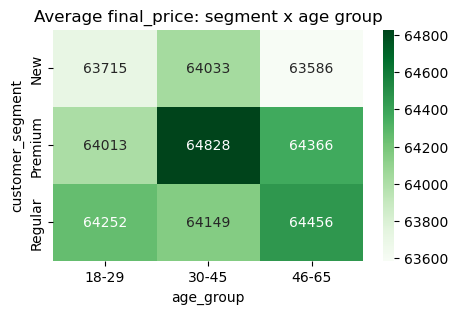

In [81]:
plt.figure(figsize=(5,3))
sns.heatmap(pivot2, annot=True, fmt=".0f", cmap="Greens")
plt.title("Average final_price: segment x age group")
plt.show()

In [82]:
print("Highest spending combination:", pivot2.stack().idxmax())

Highest spending combination: ('Premium', '30-45')


In [83]:
pivot3 = df.pivot_table(index="shipping_type", columns="delivery_days",
                        values="return_flag", aggfunc="mean") * 100
pivot3

delivery_days,1,2,3,4,5,6,7,8,9,10
shipping_type,,,,,,,,,,
Express,14.739594,14.57498,15.206082,14.579589,15.085205,14.374127,16.212425,14.757482,14.755090,14.823576
Standard,15.209508,14.80000,14.303079,14.890220,13.829365,14.916134,14.534766,15.276932,15.167549,14.184257


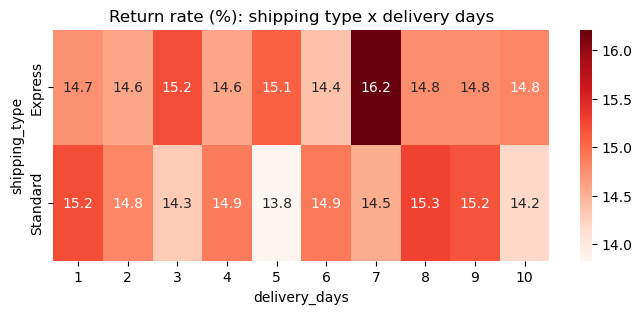

In [84]:
plt.figure(figsize=(8,3))
sns.heatmap(pivot3, annot=True, fmt=".1f", cmap="Reds")
plt.title("Return rate (%): shipping type x delivery days")
plt.show()

**SKEWNESS & KURTOSIS**

In [85]:
print("Skewness:", round(df["final_price"].skew(), 3))
print("Kurtosis:", round(df["final_price"].kurt(), 3))

Skewness: 0.935
Kurtosis: 0.169


In [86]:
df["log_final_price"] = np.log1p(df["final_price"])

In [87]:
print("Skewness after log transform:", round(df["log_final_price"].skew(), 3))

Skewness after log transform: -0.986


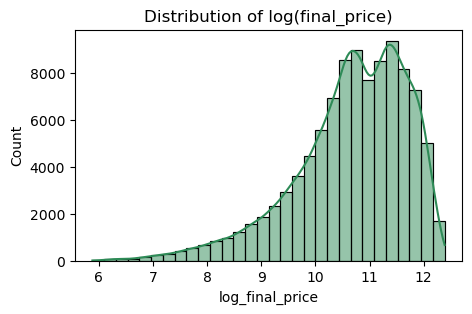

In [88]:
plt.figure(figsize=(5,3))
sns.histplot(df["log_final_price"], bins=30, kde=True, color="seagreen")
plt.title("Distribution of log(final_price)")
plt.show()

In [89]:
top_orders = df["final_price"].nlargest(int(0.10 * len(df))).sum()
print("Top 10% orders give", round(top_orders / df["final_price"].sum() * 100, 1), "% of revenue")

Top 10% orders give 26.4 % of revenue


In [90]:
monthly = df.groupby(df["order_date"].dt.to_period("M"))["final_price"].sum() / 1000000

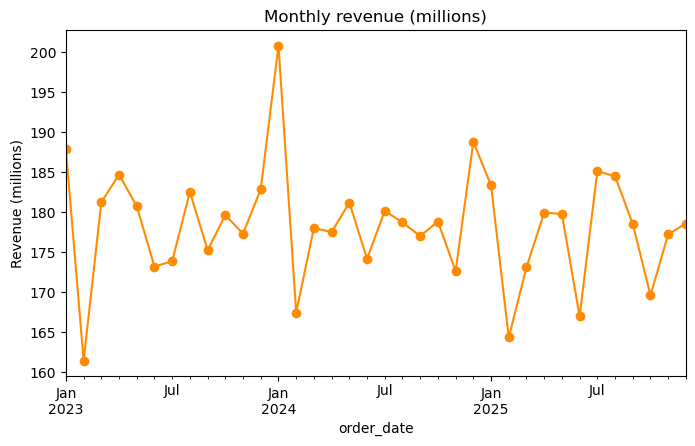

In [91]:
monthly.index = monthly.index.to_timestamp()
monthly.plot(figsize=(8, 4.5), marker="o", color="darkorange")
plt.title("Monthly revenue (millions)")
plt.ylabel("Revenue (millions)")
plt.show()